# Chapter 21: Financial Competitions: Time, Regime, and Leakage

**How far does each validation scheme's estimate drift from the model's score on the future as the label horizon grows?**

Forward-return targets overlap: today's 20-day label shares 19 days with tomorrow's. A shuffled split puts those near-copies on both sides of the boundary, and the estimate you use to choose models stops describing the future.

*Constructed data with a stable relationship; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

Eight constructed daily series in which a slow hidden state drives returns. Features are backward-looking and known at the close: a noisy reading of the state, trailing 5 and 20 day mean returns, and yesterday's return. The label is the sum of the next h returns, where h is the control. An extremely randomized trees regressor is scored by information coefficient (IC, the correlation of prediction and label, computed once over all held-out predictions) four ways on 1,500 development days: shuffled 5-fold cross-validation, walk-forward over five 150-day blocks, the same walk-forward with the last h training rows purged, and finally on about 8,000 later days the model never saw.

In [1]:
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold

from kaggle_companion.activities._common import clean

SEED = 21
REPLICATES = 8          # independent constructed series; every estimate is their mean
N_DEV, N_FUTURE = 1500, 8000
BLOCK, ORIGINS = 150, 5  # walk-forward: five chronological origins, 150-day validation blocks


def generate(horizon, seed):
    """One daily series. A slow hidden state drives returns; features are backward-looking and known at the close."""
    rng = np.random.default_rng(seed)
    burn = 100
    T = burn + N_DEV + N_FUTURE + horizon + 25
    state = np.zeros(T)
    for t in range(1, T):
        state[t] = 0.97 * state[t - 1] + rng.normal(0, 0.25)
    ret = 0.12 * state + rng.normal(0, 1.0, T)            # daily return
    observed = state + rng.normal(0, 0.5, T)              # noisy reading of the state, published at the close
    csum = np.concatenate([[0.0], np.cumsum(ret)])

    def trailing_mean(w):                                 # mean return over the w days ending today
        out = np.full(T, np.nan)
        out[w:] = (csum[w + 1:T + 1] - csum[1:T - w + 1]) / w
        return out

    X = np.column_stack([observed, trailing_mean(5), trailing_mean(20), np.r_[np.nan, ret[:-1]]])
    y = np.full(T, np.nan)
    y[:T - horizon] = csum[1 + horizon:T + 1] - csum[1:T - horizon + 1]   # label: sum of the next `horizon` returns
    rows = np.arange(burn, burn + N_DEV + N_FUTURE)
    return X[rows], y[rows]


def model():
    return ExtraTreesRegressor(n_estimators=40, min_samples_leaf=3, max_features=0.75, random_state=0, n_jobs=1)


def ic(pred, y):
    """Information coefficient: correlation between prediction and realized label."""
    return float(np.corrcoef(pred, y)[0, 1])


def one_series(horizon, seed):
    X, y = generate(horizon, seed)
    Xd, yd = X[:N_DEV], y[:N_DEV]
    Xf, yf = X[N_DEV + horizon:], y[N_DEV + horizon:]     # the future starts after the last development label resolves

    # Every scheme pools its held-out predictions and scores them once, as a final out-of-sample IC.
    shuffled = np.zeros(N_DEV)
    for a, b in KFold(5, shuffle=True, random_state=0).split(Xd):
        shuffled[b] = model().fit(Xd[a], yd[a]).predict(Xd[b])
    held = np.arange(N_DEV - ORIGINS * BLOCK, N_DEV)
    walk, purged = np.zeros(len(held)), np.zeros(len(held))
    for i, start in enumerate(range(held[0], N_DEV, BLOCK)):
        b = np.arange(start, start + BLOCK)
        walk[i * BLOCK:(i + 1) * BLOCK] = model().fit(Xd[:start], yd[:start]).predict(Xd[b])
        cut = start - horizon                             # purge: drop training rows whose label overlaps the block
        purged[i * BLOCK:(i + 1) * BLOCK] = model().fit(Xd[:cut], yd[:cut]).predict(Xd[b])
    future = ic(model().fit(Xd[:N_DEV - horizon], yd[:N_DEV - horizon]).predict(Xf), yf)
    return {"shuffled": ic(shuffled, yd), "walk_forward": ic(walk, yd[held]), "purged": ic(purged, yd[held]), "future": future}


def run(horizon):
    series = [one_series(horizon, SEED * 100 + i) for i in range(REPLICATES)]
    keys = ["shuffled", "walk_forward", "purged", "future"]
    return clean({
        "horizon": horizon,
        **{k: float(np.mean([s[k] for s in series])) for k in keys},
        "per_series": {k: [s[k] for s in series] for k in keys},
        "development_days": N_DEV, "future_days": N_FUTURE - horizon, "replicates": REPLICATES,
    })


## Measure it across the control

The control is **label horizon (days of future return in each label)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch21 import explain

VALUES = [1, 5, 10, 20]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                             1       5      10      20
Shuffled 5-fold IC       0.052   0.219   0.306   0.346
Walk-forward IC          0.045   0.116   0.178   0.191
Purged walk-forward IC   0.043   0.125   0.176   0.187
IC on the future         0.038   0.129   0.189   0.256
Shuffled minus future   +0.014  +0.091  +0.117  +0.090


## Look at it

The figure shows the default setting, label horizon (days of future return in each label) = 20.

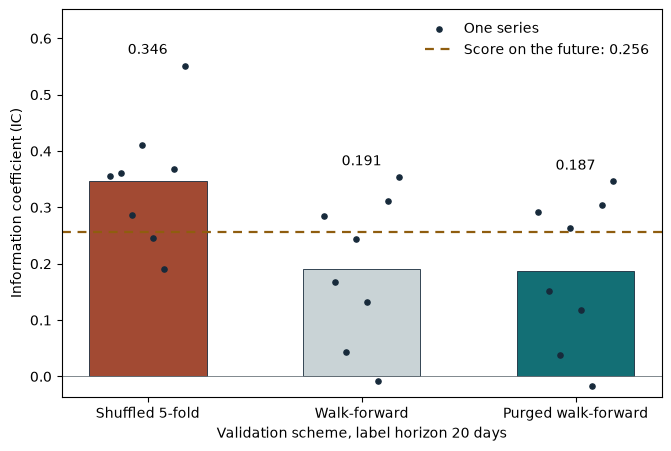

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch21 import draw, NCOLS, HEIGHT

DEFAULT = 20
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With a 20-day label horizon the model's IC on the future is 0.256. Shuffled cross-validation reports 0.346, and 0.346 - 0.256 = 0.090 is its error. Walk-forward reports 0.191 and purged walk-forward 0.187, -0.065 and -0.069 from the future. The shuffled estimate is the one that misleads.

- Shuffled: 0.346 - 0.256 = +0.090 (estimate minus future).
- Walk-forward: 0.191 - 0.256 = -0.065.
- Purged walk-forward: 0.187 - 0.256 = -0.069.
- Effect of the purge gap: 0.187 - 0.191 = -0.004.

## Apply this to your competition

- Write down the forecast time, each feature's publication time and when each label resolves before choosing a split.
- Validate forward-return targets with chronological blocks; never shuffle rows whose labels overlap in time.
- Purge at least the label horizon of training rows before every validation block, and start the final holdout after the last development label resolves.
- If a shuffled estimate and a chronological estimate disagree, trust the chronological one and look for overlapping labels or slow features.

Book location: Chapter 21, Failure Mode 2: Regime Change.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)